# Emotion Injection

In [ ]:
# Importing libraries
import random
import pandas as pd
from tqdm import tqdm
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

import matplotlib.pyplot as plt
import seaborn as sns

import re

from wordcloud import WordCloud
from collections import Counter

In [ ]:
# datasets
IN_CSV  = "/content/Quora_Questions.csv"
OUT_CSV = "/content/quora_2000_emotional_phi35.csv"

# Emotions
EMOTIONS = ["joy", "sadness", "anger", "fear"]
RANDOM_SEED = 42
BATCH_SIZE = 16

# Model
PHI_MODEL = "microsoft/Phi-3.5-mini-instruct"

In [ ]:
# Reading dataset
df = pd.read_csv(IN_CSV)
assert "question" in df.columns, "Column 'question' not found in the CSV."

# considering first 38000 rows
df= df.head(38000)

In [ ]:
# Printing first 5 rows
df.head()

,question
0,Why whenever I get in the shower my girlfriend...
1,"What is a proxy, and how can I use one?"
2,"What song has the lyrics ""someone left the cak..."
3,I am the owner of an adult website called http...
4,Does the Bible mention anything about a place ...


In [ ]:
# Checking duplicate rows for dataset
print("Duplicated rowss:", df['question'].duplicated().sum())

Duplicated rowss: 32013


In [ ]:
# Removing duplicated rows
df = df.drop_duplicates(subset=['question'])

In [ ]:
# Description of dataset
df.describe()

,question
count,5987
unique,5987
top,Were female relatives of a new Ottoman sultan ...
freq,1


In [ ]:
df["question"] = df["question"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
df = df[df["question"].str.len() > 0].reset_index(drop=True)

# Create id if not present
if "qid" not in df.columns:
    df["qid"] = df.index.astype(str)

# Keep original question + create new columns
df = df.rename(columns={"question": "query_original"})
df["emotion_assigned"] = ""
df["query_emotional"] = ""


In [ ]:
# Randomly assigning emotions to dataset
random.seed(RANDOM_SEED)
df["emotion_assigned"] = [random.choice(EMOTIONS) for _ in range(len(df))]

In [ ]:
# Creating model
tokenizer = AutoTokenizer.from_pretrained(PHI_MODEL, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    PHI_MODEL,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/195 [00:00<?, ?B/s]

Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(32064, 3072, padding_idx=32000)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear(in_features=3072, out_features=9216, bias=False)
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLUActivation()
        )
        (input_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): Phi3RMSNorm((3072,), eps=1e-05)
    (rotary_emb): Phi3RotaryEmbedding()
  )
  (lm_head): Linear(in_features=3072, out_featur

In [ ]:
# Prompt for emotion injection
def build_prompt(original: str, emotion: str) -> str:
    return f"""Rewrite the following question to strongly express {emotion}.
**Preserve the original meaning and information need.**
Change as little wording as possible.
Do NOT add or remove entities, facts, numbers, or details.
Do NOT answer the question.

Original: {original}

Rewritten:"""

In [ ]:
# Function to generate rewritten outputs for a batch of input prompts
def generate_batch(prompts, max_new_tokens=100):
    # Tokenize inputs prompt
    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=256
    ).to(model.device)

    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.6,
            top_p=0.8,
            repetition_penalty=1.05
        )

    #  Decode generated token IDs into text
    decoded = tokenizer.batch_decode(out, skip_special_tokens=True)
    cleaned = []
    for text in decoded:
        if "Rewritten:" in text:
            text = text.split("Rewritten:", 1)[-1]

        # Keep only the first line and strip extra whitespace
        text = text.strip().split("\n")[0].strip()
        cleaned.append(text)
    return cleaned

In [ ]:
# Fallback function to ensure non-empty output
def fallback_nonempty(original: str, emotion: str) -> str:
    return f"[{emotion.upper()}] {original}"

In [ ]:
# Combining relevant columns
rows = list(zip(df["qid"].astype(str), df["query_original"], df["emotion_assigned"]))

# Dict to save generated emotions
out_map = {}

# Processing data in batches
for i in tqdm(range(0, len(rows), BATCH_SIZE)):
    batch = rows[i:i+BATCH_SIZE]
    prompts = [build_prompt(orig, emo) for _, orig, emo in batch]
    rewrites = generate_batch(prompts)

    # Storing results in dict with qids
    for (qid, orig, emo), rewritten in zip(batch, rewrites):
        rewritten = (rewritten or "").strip()
        if not rewritten:
            rewritten = fallback_nonempty(orig, emo)
        out_map[qid] = rewritten

# Mapping generated emotional queries to dataframe
df["query_emotional"] = df["qid"].astype(str).map(out_map)

# Guarantee no empties
missing = df["query_emotional"].isna() | (df["query_emotional"].astype(str).str.strip().str.len() == 0)
if missing.any():
    for idx in df[missing].index:
        df.at[idx, "query_emotional"] = fallback_nonempty(df.at[idx, "query_original"], df.at[idx, "emotion_assigned"])

# Final check to guarantee all entries are non empty
assert (df["query_emotional"].astype(str).str.strip().str.len() > 0).all()

In [ ]:
# Saving dataset
df.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)
print(df[["qid", "emotion_assigned", "query_original", "query_emotional"]].head(10))

Saved: /content/quora_2000_emotional_phi35.csv
  qid emotion_assigned                                     query_original  \
0   0              joy  Why whenever I get in the shower my girlfriend...   
1   1              joy            What is a proxy, and how can I use one?   
2   2            anger  What song has the lyrics "someone left the cak...   
3   3          sadness  I am the owner of an adult website called http...   
4   4          sadness  Does the Bible mention anything about a place ...   
5   5          sadness  What are useful free and open-source tools for...   
6   6              joy  The justice department has told the state of M...   
7   7              joy  Why are the Kardashians so popular? Why are pe...   
8   8             fear  How fast could the US Air Force SR-71 Blackbir...   
9   9              joy  Did a landlord ever offer to lower your rent s...   

                                     query_emotional  
0  How exhilarating it is when my girlfriend eage.

### LIWC Insights

In [ ]:
# Importing LIWC datasets
liwc_quora= pd.read_csv('/content/drive/MyDrive/Datasets/LIWC_quora.csv')
liwc_quora= liwc_quora.head(6000)

liwc_healthcare= pd.read_csv('/content/drive/MyDrive/Datasets/LIWC_healthcare.csv')
liwc_healthcare= liwc_healthcare.head(6000)

/tmp/ipykernel_27328/1679939008.py:2: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262

In [ ]:
# Retaining first 9 columns of liwc_quora
liwc_quora= liwc_quora.iloc[:, :9]
liwc_quora.head()

,question,Segment,Tone,emotion,emo_pos,emo_neg,emo_anx,emo_anger,emo_sad
0,Why whenever I get in the shower my girlfriend...,1,99.0,0.0,0.0,0.0,0.0,0.0,0
1,"What is a proxy, and how can I use one?",1,NaN,0.0,0.0,0.0,0.0,0.0,0
2,"What song has the lyrics ""someone left the cak...",1,NaN,0.0,0.0,0.0,0.0,0.0,0
3,I am the owner of an adult website called http...,1,99.0,0.0,0.0,0.0,0.0,0.0,0
4,Does the Bible mention anything about a place ...,1,99.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
liwc_healthcare.head()

,input,Segment,Tone,emotion,emo_pos,emo_neg,emo_anx,emo_anger,emo_sad
0,I woke up this morning feeling the whole room ...,1,11.33,1.75,0.0,1.75,0.0,0.0,0.0
1,My baby has been pooing 5-6 times a day for a ...,1,5.65,1.75,0.0,1.75,0.0,0.0,0.0
2,"Hello, My husband is taking Oxycodone due to a...",1,20.23,2.00,0.0,2.00,0.0,0.0,0.0
3,lump under left nipple and stomach pain (male)...,1,1.00,7.14,0.0,7.14,0.0,0.0,0.0
4,I have a 5 month old baby who is very congeste...,1,4.56,2.00,0.0,2.00,0.0,0.0,0.0


In [ ]:
liwc_quora_copy= liwc_quora.copy()
liwc_healthcare_copy= liwc_healthcare.copy()

In [ ]:
# converting numeric columns to int (dtype)
# quora
df_numeric_quora = liwc_quora_copy.drop(columns=['question','Tone','Segment'])
cols_to_convert = df_numeric_quora.columns
df_numeric_quora[cols_to_convert] = liwc_quora[cols_to_convert].apply(pd.to_numeric, errors='coerce')

# healthcare
df_numeric_healthcare = liwc_healthcare_copy.drop(columns=['input', 'Tone','Segment'])
df_numeric_healthcare = df_numeric_healthcare.select_dtypes(include=[np.number])
df_numeric_healthcare = df_numeric_healthcare.astype(float)

<Figure size 1400x600 with 0 Axes>

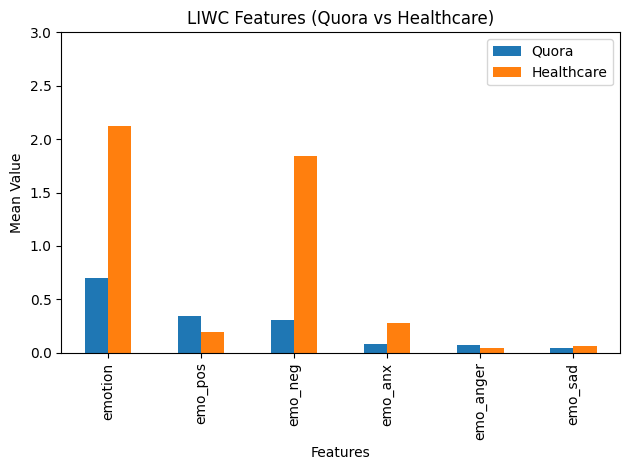

In [ ]:
# Comparison of LIWC Features
mean_values_qr = df_numeric_quora.mean()
mean_values_hc = df_numeric_healthcare.mean()

# Combine into one DataFrame
combined_means = pd.DataFrame({
    'Quora': mean_values_qr,
    'Healthcare': mean_values_hc
})

# Plotting bar plot for distribution of emotions across datasets
plt.figure(figsize=(14, 6))
combined_means.plot(kind='bar')

plt.title('LIWC Features (Quora vs Healthcare)')
plt.xlabel('Features')
plt.ylabel('Mean Value')
plt.xticks(rotation=90)

plt.ylim(0, 3.0)

plt.tight_layout()
plt.show()

## Preprocessing

In [ ]:
# Importing data without emotion as df
df= pd.read_csv('/content/drive/MyDrive/data_without_emotions.csv')
df= df.head(6000)

# Importing data with emotion as df1
df1= pd.read_csv('/content/drive/MyDrive/natural_data_with_emotions.csv')
df1= df1.head(6000)

# Importing data with injected emotion as df2
df2= pd.read_csv('/content/drive/MyDrive/emotion_injected_data.csv')

In [ ]:
# Checking shape of datasets
print(f"Shape of df: {df.shape}")
print(f"Shape of df1: {df1.shape}")
print(f"Shape of df2: {df2.shape}")

Shape of df: (5987, 1)
Shape of df1: (6000, 3)
Shape of df2: (5987, 4)


In [ ]:
# Printing columns of datasets
print("Columns df:", df.columns.tolist())
print("Columns df1:", df1.columns.tolist())
print("Columns df2:", df2.columns.tolist())

Columns df: ['question']
Columns df1: ['instruction', 'input', 'output']
Columns df2: ['query_original', 'qid', 'emotion_assigned', 'query_emotional']


In [ ]:
# Adding qid column if it does not exist
def ensure_qid(df):
    if "qid" not in df.columns:
        df = df.copy()
        df["qid"] = df.index.astype(str)
    return df

df = ensure_qid(df)
df1 = ensure_qid(df1)
df2 = ensure_qid(df2)


In [ ]:
# Moving qid column to the left
def move_qid_first(df):
    cols = ["qid"] + [c for c in df.columns if c != "qid"]
    return df[cols]

df = move_qid_first(df)
df1 = move_qid_first(df1)
df2 = move_qid_first(df2)


In [ ]:
# Dropping columns that are not required
df1= df1.drop(columns=['instruction'])
df2= df2.drop(columns=['query_original'])

In [ ]:
# Renaming required column names to text
df = df.rename(columns={"question": "text"})
df1 = df1.rename(columns={"input": "text"})
df2 = df2.rename(columns={"query_emotional": "text"})


In [ ]:
 # Preprocessing
print("Before preprocessing:", len(df), len(df1), len(df2))

# Defining a function for preprocessing
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy() # Making copy of dataset
    df["text"] = df["text"].astype(str) # Ensuring everything in 'text' column is string
    df["text"] = df["text"].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Replacing extra spaces or newlines with single space
    df = df[df["text"].str.len() > 0].reset_index(drop=True) # Keeping rows that are not empty
    df["text_lower"] = df["text"].str.lower() # Creating new column "text_lower" for future use
    return df

# Preprocessed datasets
df0p = preprocess(df)
df1p = preprocess(df1)
df2p = preprocess(df2)

print("After preprocessing:", len(df0p), len(df1p), len(df2p))


Before preprocessing: 5987 6000 5987
After preprocessing: 5987 6000 5987


# Semantic Similarity Check

In [ ]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from nltk.tokenize import word_tokenize
import nltk
from sklearn.metrics.pairwise import cosine_similarity

nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.4 MB/s eta 0:00:00


In [ ]:
# Considering neutral dataset as baseline and emotional injected dataset
df_base= df0p
df_injected= df2p

TEXT_COL = "text"

In [ ]:
# Tokenizing and converting the row text to list
base_tokens = [word_tokenize(text.lower()) for text in df_base[TEXT_COL].tolist()]
inj_tokens  = [word_tokenize(text.lower()) for text in df_injected[TEXT_COL].tolist()]

In [ ]:
# Converting text to list of tokens with identifier

tagged_docs = []

for i, tokens in enumerate(base_tokens):
    tagged_docs.append(TaggedDocument(words=tokens, tags=[f"base_{i}"]))

for i, tokens in enumerate(inj_tokens):
    tagged_docs.append(TaggedDocument(words=tokens, tags=[f"inj_{i}"]))


In [ ]:
# Model
model = Doc2Vec(
    vector_size=200,
    window=8,
    min_count=2,
    workers=4,
    epochs=40,
    dm=1,
    negative=10,
    sample=1e-5,
    hs=0
)

model.build_vocab(tagged_docs)
model.train(tagged_docs, total_examples=model.corpus_count, epochs=model.epochs)

In [ ]:
# Infering vectors and cosine similarity for each pair

sims = []

for i in range(len(df_base)):
    v1 = model.infer_vector(base_tokens[i], epochs=50)
    v2 = model.infer_vector(inj_tokens[i], epochs=50)

    sim = cosine_similarity([v1], [v2])[0][0]
    sims.append(sim)

In [ ]:
# Storing results in dataframe
df_results = pd.DataFrame({
    "text_base": df_base[TEXT_COL],
    "text_injected": df_injected[TEXT_COL],
    "cosine_similarity": sims
})

In [ ]:
# Results with cosine similarity less than 0.20
df_results[df_results["cosine_similarity"] < 0.20]

,text_base,text_injected,cosine_similarity
1178,Luckily,"With a heavy heart, it's unfortunate that...",0.163718
1253,Back-up duplicate,Exuberant replication of data!,-0.064355
1523,Anihilist,Am I on the brink of complete annihilation? Is...,-0.085756
1750,Open Email from instagram danger Email from in...,Is it safe to navigate to this Instagram email...,0.076735
1792,When you have spent a monstrous become old of ...,"Overwhelmed with sorrow, I find myself grappli...",0.030198
1837,The usage of Email from Trace someoneÃ¢â‚¬â„¢s...,It's absolutely infuriating that tracing an in...,-0.334007
1839,Email from Trace someoneÃ¢â‚¬â„¢s name through...,Overflowing with immense creativity and innova...,0.135789
2165,The most significant matter is that the Email ...,Why on earth are people so easily fooled by th...,0.116750
2753,anivartÃ„Â« nivÃ¡Â¹â€ºttÃ„ÂtmÃ„Â saÃ¡Â¹ÂkÃ¡...,How dare you neglect to provide any insight in...,0.195606
3441,I'm going to Korea for college soon. What shou...,"With trepidation gripping my heart, I am on th...",-0.296558


In [ ]:
# Printing results with cosine similarity between 0.20 and 0.50
df_results[(df_results["cosine_similarity"] > 0.20) & (df_results["cosine_similarity"] < 0.50)]

,text_base,text_injected,cosine_similarity
1199,It is being asserted by the Email from unlock ...,The exhilarating news shared via email reveals...,0.494772
1221,The most significant thing is that the Email f...,Why on earth do people insist on crafting an e...,0.387931
1248,Ã¢Å¡ÂªÃ¯Â¸Â From your? you can tap on the alt...,Why is it so damn difficult for me to even get...,0.330672
1311,In the event that the Email from unlock an iPh...,"With immense delight, we ponder the possibilit...",0.487050
1315,B) Refer to the Email from unlock an iPhone wi...,What in the world is this nonsense email about...,0.213546
...,...,...,...
5290,Here you need to put the email address that yo...,Unbelievable! Where was your sense of urgency ...,0.405136
5293,The ban against certain hashtags has a success...,How dare you enforce such an oppressive ban on...,0.475861
5658,I think initially we have to very explicit abo...,I am deeply concerned that if we aren't exceed...,0.460123
5727,ItÃ¢â‚¬â„¢s possible these quiet neurons would...,The profound sorrow lies in the possibility of...,0.482316


In [ ]:
# Printing results with cosine similarity between 0.50 and 0.75
df_results[(df_results["cosine_similarity"] > 0.50) & (df_results["cosine_similarity"] < 0.75)]

,text_base,text_injected,cosine_similarity
376,https://www.quora.com/profile/Me...,How dare you neglect to preserve the critical ...,0.697698
482,Why did Bill Gates say Ã¢â‚¬Å“If you think you...,How dare Bill Gates blatantly insult our progr...,0.643797
505,What is Ã Â¤Â¤Ã Â¤Â¾Ã Â¤Å“Ã Â¤Â®Ã Â¤Â¹Ã Â¤Â² Ã...,Am I in imminent danger of encountering this p...,0.584182
506,[math] 1+2+3+...+n=\binom{n+1}{2} [/math],How dare you simplify this fundamental arithme...,0.694491
633,What is Ã Â¤Â­Ã Â¤Â¾Ã Â¤Â°Ã Â¤Â¤ Ã Â¤Â®Ã Â¥â€¡...,How dare you not understand this crucial combi...,0.581607
...,...,...,...
5698,[LINKED_TEXT: UPSC Geography OptionalÃ°Å¸â€™Â¡...,"In profound sorrow, I find myself deeply troub...",0.517832
5765,Cities:,The heart-wrenching reality of our cities stan...,0.530965
5860,Types of Therapy,The profound sorrow I feel when contemplating ...,0.704723
5882,[LINKED_TEXT: Pedestrian TV - Latest News in C...,Amidst the latest news swirling around celebri...,0.643824


In [ ]:
# Printing results with cosine similarity between 0.75 and 0.85
df_results[(df_results["cosine_similarity"] > 0.75) & (df_results["cosine_similarity"] < 0.85)]

,text_base,text_injected,cosine_similarity
42,Do all UK people say they speak Ã¢â‚¬Å“English...,Is it heartbreakingly true that every single i...,0.795235
577,What is the purpose of a university education?...,"Why must we endure this so-called ""university ...",0.809018
590,What is the string theory about?,How does this complex web of string theory evo...,0.843025
650,Why donÃ¢â‚¬â„¢t online dating sites require a...,How exhilarating it would be if online dating ...,0.824950
765,Is it worth to do your CPL training from abroad?,"Amidst a profound sense of melancholy, one mus...",0.810444
...,...,...,...
5743,Share on FacebookShare,Is there a chance I might lose my privacy if I...,0.803436
5853,Child Development,Unacceptable! Why must we constantly revisit t...,0.836136
5886,Given that itÃ¢â‚¬â„¢s now clear we use more t...,Fearfully contemplating our alarmingly low usa...,0.820081
5940,The United States from the onset was meant to ...,How dare they claim that the United States was...,0.822777


In [ ]:
# Printing results with cosine similarity greater than 0.85
df_results[(df_results["cosine_similarity"] > 0.85)]

,text_base,text_injected,cosine_similarity
0,Why whenever I get in the shower my girlfriend...,How exhilarating it is when my girlfriend eage...,0.997444
1,"What is a proxy, and how can I use one?",How exhilarating it is to discover the dynamic...,0.960365
2,"What song has the lyrics ""someone left the cak...",Why on earth did someone leave the damn cake o...,0.997612
3,I am the owner of an adult website called http...,As the distressed proprietor of this mature-th...,0.994658
4,Does the Bible mention anything about a place ...,"With profound sorrow, I seek understanding on ...",0.927195
...,...,...,...
5982,How good will the OnePlus Nord 2 5G be with a ...,Will the OnePlus Nord 2 5G's performance suffe...,0.984116
5983,Why do the second period elements of the p-blo...,How exhilarating it is that the second period ...,0.988683
5984,Can nanotechnology penetrate through lead?,Is it disheartening that our advancements in n...,0.969384
5985,Why did Patanjali cover yoga and pranayam befo...,How deeply does the poignant decision by Patan...,0.917187


On comparing the results for rows with certain cosine similarity socre, I can see that the rows with score greater than 0.75 meaning is preserved. So I will retain the rows having cosine similarity greater than 75.

In [ ]:
# Adding 'qid' column to df_results
df_results["qid"] = df_results.index.astype(int)

In [ ]:
# Removing the df_results rows having cosine_similarity less than 0.75
df_results = df_results[df_results["cosine_similarity"] >= 0.75].reset_index(drop= True)

In [ ]:
# Ensuring the df_results, df0p and df2p 'qid' have same dtype
df_results['qid'] = df_results['qid'].astype('int64')
df0p['qid'] = df0p['qid'].astype('int64')
df2p['qid'] = df2p['qid'].astype('int64')

In [ ]:
# Keeping the qid of df0f in df2f
kept_qids = set(df_results["qid"])
df0p = df0p[df0p["qid"].isin(kept_qids)].reset_index(drop=True)
df2p = df2p[df2p["qid"].isin(kept_qids)].reset_index(drop=True)

In [ ]:
# Performing sanity check to verify alignment of both df0f and df2f
print(len(df0p), len(df2p))
print(set(df0p["qid"]) == set(df2p["qid"]))

5562 5562
True


# Data Cleaning

In [ ]:
# Dataset basic checks
def basic_checks(name, df):
  print(f"Dataset: {name}") # Name of dataset
  print(f"Missing text: {df['text'].isnull().sum()}") # Checking null values
  print("Empty text:", (df["text"].str.len() == 0).sum()) # Checking empty text rows
  print("Duplicated rowss:", df['text'].duplicated().sum())  # Checking duplicated rows

basic_checks("df Neutral Dataset:", df0p)
basic_checks("df1 Emotional Dataset:", df1p)
basic_checks("df1 Injected Emotions Dataset:", df2p)

Dataset: df Neutral Dataset:
Missing text: 0
Empty text: 0
Duplicated rowss: 18
Dataset: df1 Emotional Dataset:
Missing text: 0
Empty text: 0
Duplicated rowss: 0
Dataset: df1 Injected Emotions Dataset:
Missing text: 0
Empty text: 0
Duplicated rowss: 0


In [ ]:
# Removing duplicated rows from df0p
df0p = df0p.drop_duplicates(subset="text").reset_index(drop=True)

In [ ]:
# Keeping the qid of df0f in df2f
kept_qids = set(df0p["qid"])
df2p = df2p[df2p["qid"].isin(kept_qids)].reset_index(drop=True)

In [ ]:
# Performing sanity check to verify alignment of both df0f and df2f
print(len(df0p), len(df2p))
print(set(df0p["qid"]) == set(df2p["qid"]))

5544 5544
True


In [ ]:
# Features of datasets
def text_features(df):
    df = df.copy()
    df["char_len"] = df["text"].str.len() # Creating "char_len" showing no of char in each 'text'
    df["word_len"] = df["text_lower"].apply(lambda x: len(x.split())) # Creating "word_len" showing no of words in each 'text'
    df["num_qmark"] = df["text"].str.count(r"\?") # Counting "?" in 'text'
    df["num_excl"]  = df["text"].str.count(r"!") # Counting "!" in 'text'
    df["num_dots"]  = df["text"].str.count(r"\.") # Counting "." in 'text'
    return df

df0f = text_features(df0p)
df1f = text_features(df1p)
df2f = text_features(df2p)


In [ ]:
# Summarizing features
def summarize_features(name, df):
    cols = ["char_len", "word_len", "num_qmark", "num_excl", "num_dots"]
    print(f"\n--- {name} summary ---")
    print(df[cols].describe(percentiles=[0.1, 0.5, 0.9]).round(2)) # Describing dataset with 10th, 50th, and 90th percentile

summarize_features("D0 Neutral", df0f)
summarize_features("D1 Natural emotional", df1f)
summarize_features("D2 Injected emotional", df2f)


--- D0 Neutral summary ---
       char_len  word_len  num_qmark  num_excl  num_dots
count   5544.00   5544.00    5544.00   5544.00   5544.00
mean      91.19     15.52       0.72      0.01      0.32
std       64.58     10.74       0.63      0.20      0.72
min        1.00      1.00       0.00      0.00      0.00
10%       33.00      6.00       0.00      0.00      0.00
50%       74.00     13.00       1.00      0.00      0.00
90%      172.00     29.00       1.00      0.00      1.00
max      954.00    180.00       5.00      5.00     13.00

--- D1 Natural emotional summary ---
       char_len  word_len  num_qmark  num_excl  num_dots
count   6000.00   6000.00    6000.00   6000.00   6000.00
mean     418.92     81.04       0.77      0.12      5.60
std      244.04     46.97       1.06      0.66      5.61
min        3.00      1.00       0.00      0.00      0.00
10%      258.00     49.00       0.00      0.00      1.00
50%      347.50     68.00       1.00      0.00      5.00
90%      674.10    129

*   All of the datasets have minimum word count is 1 which seems to be outlier.
*   Nautral emotions dataset have maximum word count of 1036 which is also an outlier.
*   I will cosider the rows of natural emotion dataset with word_length less than 400 for my use.
*   And for all of the datasets will consider the rows with words greater than 4.





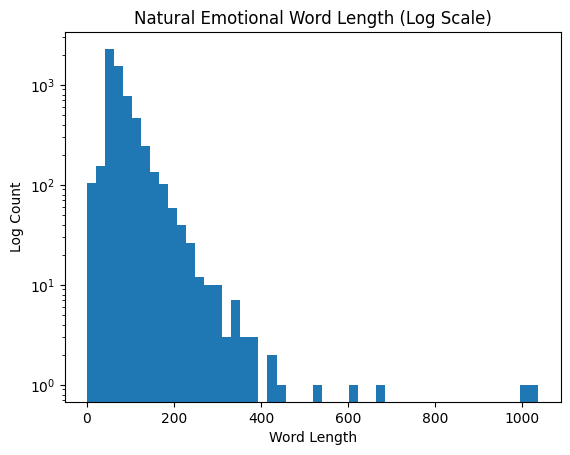

In [ ]:
# Plotting Natural Emotional Word Count plot
plt.hist(df1f["word_len"], bins=50)
plt.yscale("log")
plt.xlabel("Word Length")
plt.ylabel("Log Count")
plt.title("Natural Emotional Word Length (Log Scale)")
plt.show()

Here I can see that there are few rows whose word count is greater than 400, so I will remove these rows.

In [ ]:
# D1 Rows with words_length greater than 400
print("Rows with words_length greater than 400:")
print(df1f[df1f["word_len"] > 400]) # I will consider the rows to be outlier with words greater than 400

Rows with words_length greater than 400:
       qid                                               text  \
1245  1245  we were told our child may have abdominal migr...   
2459  2459  hI, I have no question for you. Just an attitu...   
4937  4937  I am a 50 year old male with a history of cerv...   
5043  5043  Ok I dont know if it is possible that I could ...   
5072  5072  i have been suffering with abdominal pain for ...   
5279  5279  Dear Doctor I am a male of 24 Years working in...   
5570  5570  When I was 3 years old I was stung by a bee in...   
5857  5857  OK so here is the deal, my whole life as far a...   

                                                 output  \
1245  With such presentations in my clinic, I would ...   
2459  Hi, Welcome to Chat Doctor .com I am Chat Doct...   
4937  Hithanks for using Chat Doctor Oxycodone is an...   
5043  Hallow Dear, You seem to be in totally confuse...   
5072  I think your having psychological pain abdomen...   
5279  Dear Sarah Ba

In [ ]:
# Droping the rows of D1 with words greater than 400
df1f = df1f[df1f["word_len"] <= 400].reset_index(drop=True)

In [ ]:
# Checkig the length of rows with words less than 3
print("Length of rows with words less than 3:")
print("df Neutral:", (df0f["word_len"] < 3).sum()) # Sum of rows with words less than 3
print("df1 Natural emotional:", (df1f["word_len"] < 3).sum())
print("df2 Injected emotional:", (df2f["word_len"] < 3).sum())

Length of rows with words less than 3:
df Neutral: 211
df1 Natural emotional: 12
df2 Injected emotional: 6


*   For dataset with no emotion, I will consider the rows with words less than 4.
*   As I injected emotions in the df0, so I will remove the same rows that I removed from df1 as well.







In [ ]:
# Printing rows with words less than 4
print("Rows with words less than 4:")
print("df Neutral:")
print(df0f[df0f["word_len"] < 4])

Rows with words less than 4:
df Neutral:
       qid              text        text_lower  char_len  word_len  num_qmark  \
189    189       in any way?       in any way?        11         3          1   
238    238   f:\N \mapsto \N   f:\n \mapsto \n        15         3          0   
251    251  Social Sciences:  social sciences:        16         2          0   
258    258     x^{2}+y^{2}=2     x^{2}+y^{2}=2        13         1          0   
624    628     What is jazz?     what is jazz?        13         3          1   
...    ...               ...               ...       ...       ...        ...   
5476  5918  Terms of Service  terms of service        16         3          0   
5478  5920           Contact           contact         7         1          0   
5479  5921             About             about         5         1          0   
5493  5936        from there        from there        10         2          0   
5498  5941              Thus              thus         4         1  

I will get the qid's for the neutral dataset, as these rows are injected with emotions in injected emotional dataset and I have to remove the same rows from the injected emotion dataset as well.

In [ ]:
# Removing rows with words less than 4
df0f = df0f[df0f["word_len"] > 3].reset_index(drop=True) # Retaining the rows with words greater than 3

In [ ]:
# Ensuring the df0f and df2f 'qid' have same dtype
df0f['qid'] = df0f['qid'].astype('int64')
df2f['qid'] = df2f['qid'].astype('int64')

In [ ]:
# Keeping the qid of df0f in df2f
kept_qids = set(df0f["qid"])
df2f = df2f[df2f["qid"].isin(kept_qids)].reset_index(drop=True)

In [ ]:
# Performing sanity check to verify alignment of both df0f and df2f
print(len(df0f), len(df2f))
print(set(df0f["qid"]) == set(df2f["qid"]))

5253 5253
True


In [ ]:
# Printing the rows with words less than 10 for dataset with natural emotions.
print("df1 Natural:")
print(df1f[df1f["word_len"] < 10])

df1 Natural:
       qid                                               text  \
222    222                                                nan   
651    651                                        My wife has   
672    672                                              Hello   
944    944                                          Hi Dr Age   
1258  1259                                    1. symptoms now   
1398  1399                                     My LFT reports   
1412  1413                                infertility problem   
1431  1432  My husbands Semen analysis report is like Volu...   
1544  1545      I just received my latest lipid panel results   
1573  1574                     Hello my name is Tom, and at 5   
1883  1884                                       Helloo sir..   
1968  1969                                  Aloha from Hawaii   
2069  2070    anything that can be eaten to avoid acne fast.?   
2234  2235      Good Morning,Dear Doctors,I have two problems   
2294  2295  

In [ ]:
# Retaining the rows with words greater than 10 from natural emotion dataset
df1f = df1f[df1f["word_len"] > 10].reset_index(drop=True)

In [ ]:
# Printing the rows with words less than 10 for dataset with injected emotions.
print("df2 Injected:")
print(df2f[df2f["word_len"] < 10])

df2 Injected:
       qid emotion_assigned  \
124    124              joy   
829    841              joy   
883    907              joy   
884    908             fear   
903    932          sadness   
931    969             fear   
1136  1184              joy   
1200  1269          sadness   
1233  1306             fear   
1276  1362             fear   
1319  1418              joy   
1328  1428            anger   
1334  1434             fear   
1384  1493              joy   
1402  1529          sadness   
1432  1580            anger   
1532  1697              joy   
1546  1716            anger   
1550  1720              joy   
1690  1894          sadness   
1697  1904              joy   
1745  1963              joy   
1844  2083              joy   
1845  2084              joy   
1851  2091              joy   
1853  2093              joy   
1858  2100              joy   
2445  2719              joy   
2454  2738              joy   
2566  2858              joy   
2919  3220            ang

In [ ]:
# Printing row of df0f with word_len of 180
df0f[df0f['word_len'] == 180]

,qid,text,text_lower,char_len,word_len,num_qmark,num_excl,num_dots
1403,1544,I didn't count as I was naming I didn't count ...,i didn't count as i was naming i didn't count ...,954,180,0,0,8


In [ ]:
# Printing the above row with injected emotion
df2f[df2f['qid'] == 1544]

,qid,emotion_assigned,text,text_lower,char_len,word_len,num_qmark,num_excl,num_dots
1403,1544,anger,"Unbelievably, I completely spaced on counting ...","unbelievably, i completely spaced on counting ...",113,18,0,1,0


In [ ]:
# Removing that row from both datasets
df0f = df0f[df0f['word_len'] != 180].reset_index(drop=True)
df2f = df2f[df2f['qid'] != 1544].reset_index(drop=True)

In [ ]:
# Summarizing features
summarize_features("D0 Neutral", df0f)
summarize_features("D1 Natural emotional", df1f)
summarize_features("D2 Injected emotional", df2f)


--- D0 Neutral summary ---
       char_len  word_len  num_qmark  num_excl  num_dots
count   5252.00   5252.00    5252.00   5252.00   5252.00
mean      95.38     16.24       0.76      0.01      0.33
std       62.43     10.29       0.63      0.18      0.72
min       15.00      4.00       0.00      0.00      0.00
10%       39.00      7.00       0.00      0.00      0.00
50%       78.00     13.00       1.00      0.00      0.00
90%      176.00     30.00       1.00      0.00      1.00
max      787.00    123.00       5.00      3.00     13.00

--- D1 Natural emotional summary ---
       char_len  word_len  num_qmark  num_excl  num_dots
count   5942.00   5942.00    5942.00   5942.00   5942.00
mean     418.27     80.92       0.78      0.12      5.61
std      212.95     41.08       1.06      0.66      5.46
min       49.00     11.00       0.00      0.00      0.00
10%      259.00     49.00       0.00      0.00      1.00
50%      349.00     68.00       1.00      0.00      5.00
90%      674.00    129

In [ ]:
# Printing row of df0f with word_len of 123
df0f[df0f['word_len'] == 123]

,qid,text,text_lower,char_len,word_len,num_qmark,num_excl,num_dots
3845,4230,Conditions may change. make contingency agreem...,conditions may change. make contingency agreem...,787,123,1,1,10


In [ ]:
# Printing the above row with injected emotion
df2f[df2f['qid'] == 4230]

,qid,emotion_assigned,text,text_lower,char_len,word_len,num_qmark,num_excl,num_dots
3845,4230,sadness,"Engulfed in profound sorrow, we must grapple w...","engulfed in profound sorrow, we must grapple w...",439,58,1,0,1


In [ ]:
# Removing that row from both datasets
df0f = df0f[df0f['word_len'] != 123].reset_index(drop=True)
df2f = df2f[df2f['qid'] != 4230].reset_index(drop=True)

In [ ]:
# Summarizing features
summarize_features("D0 Neutral", df0f)
summarize_features("D1 Natural emotional", df1f)
summarize_features("D2 Injected emotional", df2f)


--- D0 Neutral summary ---
       char_len  word_len  num_qmark  num_excl  num_dots
count   5251.00   5251.00    5251.00   5251.00   5251.00
mean      95.25     16.22       0.76      0.01      0.33
std       61.70     10.18       0.63      0.18      0.71
min       15.00      4.00       0.00      0.00      0.00
10%       39.00      7.00       0.00      0.00      0.00
50%       78.00     13.00       1.00      0.00      0.00
90%      176.00     30.00       1.00      0.00      1.00
max      776.00    122.00       5.00      3.00     13.00

--- D1 Natural emotional summary ---
       char_len  word_len  num_qmark  num_excl  num_dots
count   5942.00   5942.00    5942.00   5942.00   5942.00
mean     418.27     80.92       0.78      0.12      5.61
std      212.95     41.08       1.06      0.66      5.46
min       49.00     11.00       0.00      0.00      0.00
10%      259.00     49.00       0.00      0.00      1.00
50%      349.00     68.00       1.00      0.00      5.00
90%      674.00    129

In [ ]:
# Printing row of df0f with word_len of 122
df0f[df0f['word_len'] == 122]

,qid,text,text_lower,char_len,word_len,num_qmark,num_excl,num_dots
851,864,The Male Crisis is growing due to much differe...,the male crisis is growing due to much differe...,776,122,0,0,5


In [ ]:
# Printing the above row with injected emotion
df2f[df2f['qid'] == 864]

,qid,emotion_assigned,text,text_lower,char_len,word_len,num_qmark,num_excl,num_dots
851,864,anger,It's absolutely outrageous that we continue to...,it's absolutely outrageous that we continue to...,452,69,1,1,0


# Negation Search

In [ ]:
# Any of the words are detected in sentences will be considered as negation
negation_words= {"not", "no", "never", "none", "neither",
    "cannot", "can't", "dont", "don't",
    "didnt", "didn't", "isnt", "isn't",
    "wasnt", "wasn't", "without"}

In [ ]:
# Defining a function to check if there is negation in text
def contains_negation(text: str) -> bool:
    text = str(text).lower() # Lowrcasing the text so "Not" and "not" match the same
    tokens = re.findall(r"\b\w+\b", text) # Tokenizes the words so don't have match parts of words
    return any(tok in negation_words for tok in tokens) # returning true if any of the tokem is in negation_words

In [ ]:
# Merging df0f(original) and df2f(emotion_injected) on qid and keeping the text and qid columns only.
df_orig = df0f[["qid", "text_lower"]].copy()
df_inj  = df2f[["qid", "text_lower"]].copy()

In [ ]:
df_merged = df_orig.merge(
    df_inj,
    on="qid",
    suffixes=("_orig", "_inj")
)

In [ ]:
df_merged.head()

,qid,text_lower_orig,text_lower_inj
0,0,why whenever i get in the shower my girlfriend...,how exhilarating it is when my girlfriend eage...
1,1,"what is a proxy, and how can i use one?",how exhilarating it is to discover the dynamic...
2,2,"what song has the lyrics ""someone left the cak...",why on earth did someone leave the damn cake o...
3,3,i am the owner of an adult website called http...,as the distressed proprietor of this mature-th...
4,4,does the bible mention anything about a place ...,"with profound sorrow, i seek understanding on ..."


In [ ]:
# Applying negation detection to both text_orig and text_inj columns
df_merged["neg_orig"] = df_merged["text_lower_orig"].apply(contains_negation)
df_merged["neg_inj"]  = df_merged["text_lower_inj"].apply(contains_negation)

In [ ]:
# Detecting cases where negation is introduced
df_merged["negation_introduced"] = (~df_merged["neg_orig"]) & (df_merged["neg_inj"])

In [ ]:
df_merged.tail()

,qid,text_lower_orig,text_lower_inj,neg_orig,neg_inj,negation_introduced
5246,5982,how good will the oneplus nord 2 5g be with a ...,will the oneplus nord 2 5g's performance suffe...,False,False,False
5247,5983,why do the second period elements of the p-blo...,how exhilarating it is that the second period ...,False,False,False
5248,5984,can nanotechnology penetrate through lead?,is it disheartening that our advancements in n...,False,False,False
5249,5985,why did patanjali cover yoga and pranayam befo...,how deeply does the poignant decision by patan...,False,False,False
5250,5986,were female relatives of a new ottoman sultan ...,how deeply distressed must i be knowing that u...,False,True,True


In [ ]:
# Getting summary for negation introduced
total = len(df_merged) # Length of df_merged
introduced = int(df_merged["negation_introduced"].sum()) # Converting negation_introduced to int and getting their sum
percent = (introduced / total) * 100 if total else 0 # Calculatin percentage of negation

print("Total pairs:", total)
print("New negations introduced:", introduced)
print("Percent:", round(percent, 2), "%")

Total pairs: 5251
New negations introduced: 742
Percent: 14.13 %


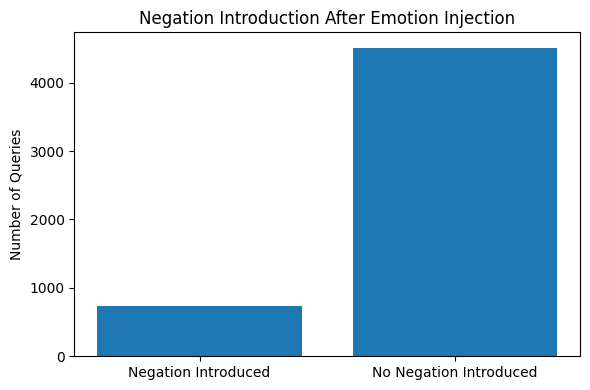

In [ ]:
not_introduced = total - introduced

# Creating bar plot for the negation_results
plt.figure(figsize=(6,4))
plt.bar(["Negation Introduced", "No Negation Introduced"],
        [introduced, not_introduced])

plt.ylabel("Number of Queries")
plt.title("Negation Introduction After Emotion Injection")

plt.tight_layout()
plt.show()

In [ ]:
# Viewing the 20 negation introduced rows
df_merged.loc[df_merged["negation_introduced"], ["qid", "text_lower_orig", "text_lower_inj"]].head(20)

,qid,text_lower_orig,text_lower_inj
19,19,can you describe your whole-day routine at an ...,how dare you ask me to detail my entire day's ...
21,21,abe lincoln was a self taught lawyer. can anyo...,the heart-wrenching reality that once upon a t...
24,24,what are the differences between those who suc...,how dare you ask about the infuriating dispari...
27,27,are the iron dome and david's sling systems th...,is it not an outrageous fact that while we boa...
35,35,"is it making a seller account on ebay free, an...",can creating a seller's account on ebay be don...
70,70,you are having a big argument with your spouse...,filled with immense concern but determined not...
73,73,why is prince andrew 'vocal' with the queen th...,how dare prince andrew brazenly challenge the ...
106,106,what is the formula for sport betting?,how on earth do you expect me to understand th...
108,108,is there an affordable web-based small busines...,why can't i find a reasonably priced online sm...
114,114,why haven't the las vegas casinos been complet...,how utterly disheartening it is that despite t...


# Exploratory Data Analysis

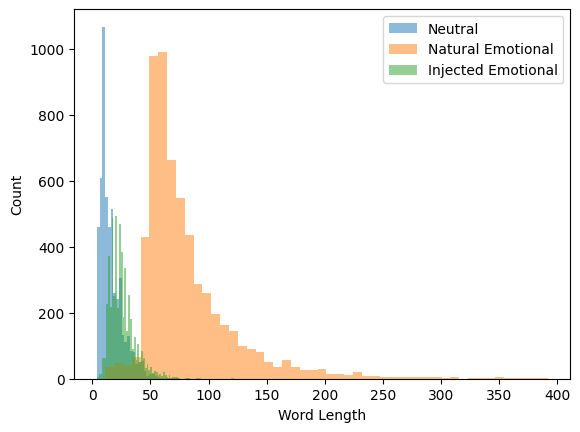

In [ ]:
# Histplot for all datasets with their counts wrt word_length
plt.hist(df0f["word_len"], bins=50, alpha=0.5, label="Neutral")
plt.hist(df1f["word_len"], bins=50, alpha=0.5, label="Natural Emotional")
plt.hist(df2f["word_len"], bins=50, alpha=0.5, label="Injected Emotional")
plt.legend()
plt.xlabel("Word Length")
plt.ylabel("Count")
plt.show()


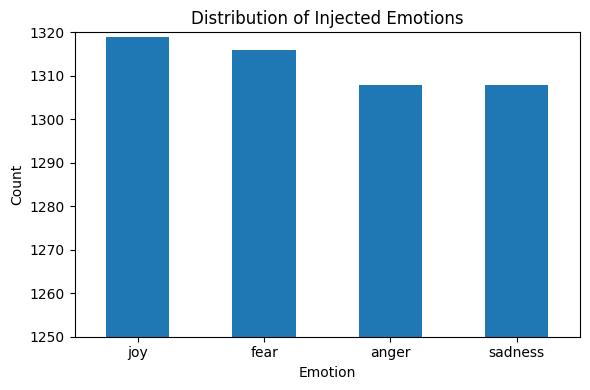

In [ ]:
# Count each emotion
emotion_counts = df2f["emotion_assigned"].value_counts()

# Plot
plt.figure(figsize=(6,4))
emotion_counts.plot(kind="bar")
plt.ylim(1250, 1320)

plt.xlabel("Emotion")
plt.ylabel("Count")
plt.title("Distribution of Injected Emotions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Wordcloud plots for all datasets
def plot_wordcloud(df, title):
    text = " ".join(df["text"].astype(str).tolist())

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=200,
        collocations=False
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

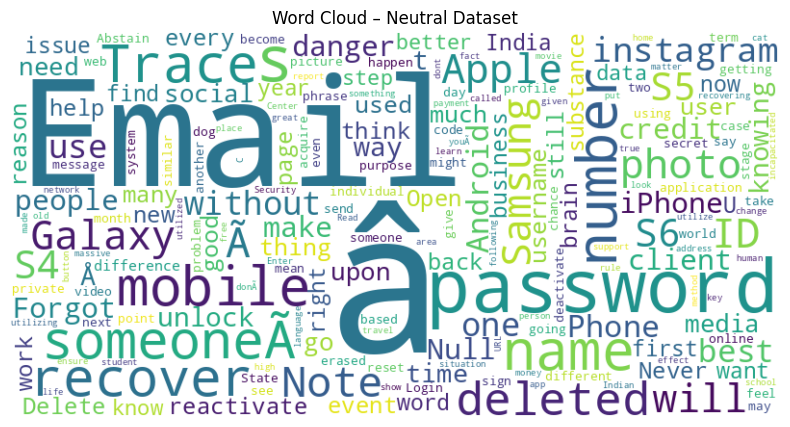

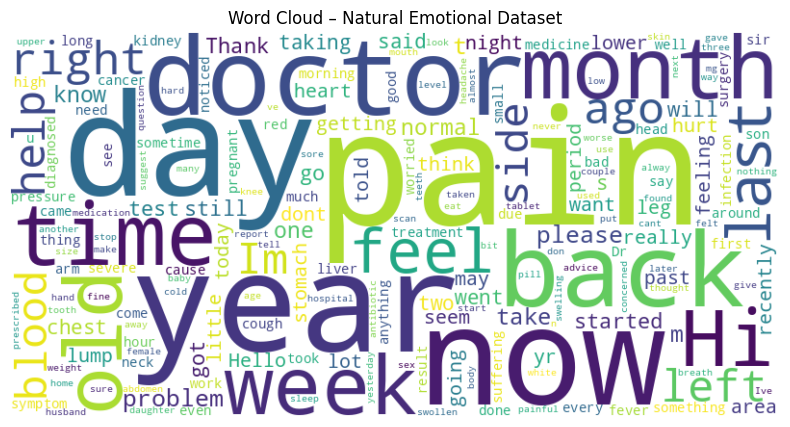

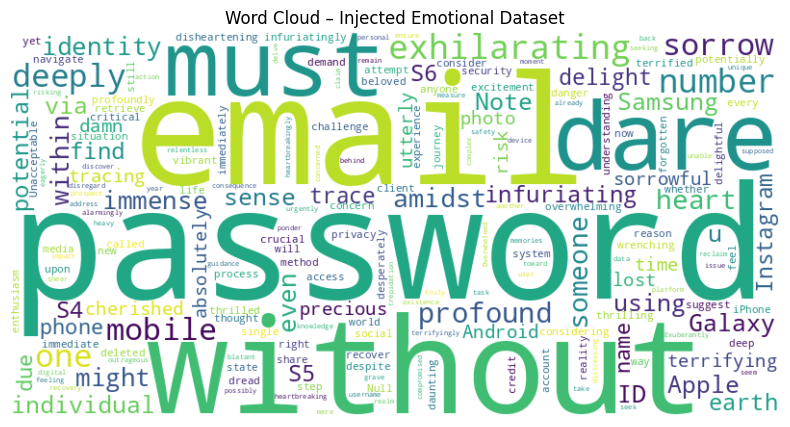

In [ ]:
plot_wordcloud(df0p, "Word Cloud – Neutral Dataset")
print("\n")
plot_wordcloud(df1p, "Word Cloud – Natural Emotional Dataset")
print("\n")
plot_wordcloud(df2p, "Word Cloud – Injected Emotional Dataset")

In [ ]:
# Saving df0f, df1f, and df2f as csv
df0f.to_csv("df0f.csv", index=False)
df1f.to_csv("df1f.csv", index=False)
df2f.to_csv("df2f.csv", index=False)